### Evaluate calculation to yield best hyperparameters

In [1]:
from qugen.main.data.data_handler import TabularDataTransformer as tdf
from qugen.main.generator.discrete_qgan_model_handler import (
    DiscreteQGANModelHandler,
)

In [2]:
import glob
import json
import os

from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

import numpy as np
import pandas as pd

In [4]:
evaluation_metric = "overall"
data_set_name: str = 'mimic_10'

In [89]:
root_path =  os.getcwd()
data_set_path = f"./../training_data/{data_set_name}.csv"
meta_path = f"./../training_data/{data_set_name}_meta.json"
training_data = pd.read_csv(data_set_path, dtype={"combined": str})["combined"].values
training_data = np.array(list(list(map(int, list(d))) for d in training_data))
num_samples = data_lenght = len(training_data)

In [90]:
with open(meta_path, 'r') as f:
        meta_file = f.read()
meta_file = meta_file.replace("'", '"')
training_meta_data = json.loads(meta_file)
data_spec = training_meta_data['data_spec']
n_qubits = training_meta_data['n_qubits']
column_names = training_meta_data['column_names']


In [18]:
## TODO: Subset dataframe to disregard numerical column names
# Quantum generated samples have additional column names, even after "readable" transformation


In [91]:
original_data = tdf.decode_tabular_data(
    pd.DataFrame(training_data[:data_lenght]), data_spec, column_names
)
# original_data = original_data.iloc[:, n_qubits:]

In [92]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(original_data)
metadata

{
    "columns": {
        "AGE": {
            "sdtype": "numerical"
        },
        "GENDER": {
            "sdtype": "categorical"
        },
        "ADMISSION_TYPE": {
            "sdtype": "categorical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1"
}

In [3]:
def overlap_counter(samples, training_data):
    training_data = pd.DataFrame(training_data)
    training_data.loc[:,'combined'] = training_data.apply(lambda x:  ''.join(map(str, x.values)), axis =1)
    samples = pd.DataFrame(samples)
    samples.loc[:,'combined'] = samples.apply(lambda x:  ''.join(map(str, x.values)), axis =1)
    training_data_unique  = set(training_data.combined)
    samples_unique = set(samples.combined)
    difference = set(samples_unique) - set(training_data_unique)
    unique_fraction = len(difference) / len(samples_unique)

    return  1 - unique_fraction


In [21]:
def evaluate_samples(generated_samples, training_samples, metric):
    # skip transformation when classical
    train_data_readable_space = training_samples

    # print(generated_samples[:num_samples])

    # generated_data_readable_space = tdf.decode_tabular_data(
    #     pd.DataFrame(generated_samples[:num_samples]),
    #     data_spec,
    #     column_names,
    # )
    generated_data_readable_space = generated_samples

    # TODO: Find out where to import this from
    # from sdv.evaluation.single_table import evaluate_quality
    
    if metric == "overall":
        quality_report = evaluate_quality(
            real_data=train_data_readable_space,
            synthetic_data=generated_data_readable_space,
            metadata=metadata,
            verbose=False,
        )
        overall_metric = quality_report.get_score()
        metric = overall_metric
    else:
        raise ValueError
    return metric

In [98]:
# load raw data from file 

In [4]:
experiments_dir_root = "./../../../experiments/experiments_quriousity_13/*/"
# experiments_dir = f"{experiments_dir_root}experiments/*/"
meta_files = glob.glob(os.path.join(experiments_dir_root, "*meta.json"))
results_files = glob.glob(os.path.join(experiments_dir_root, "overall*.csv"))
len(meta_files)

40

In [25]:
experiments_dir_root_classical = "./../../../experiments/experiments_quriousity_13/classical/*/"
# experiments_dir = f"{experiments_dir_root}experiments/*/"
meta_files_classical = glob.glob(os.path.join(experiments_dir_root_classical, "*meta.json"))
results_files_classical = glob.glob(os.path.join(experiments_dir_root_classical, "overall*.csv"))
len(meta_files_classical)

80

In [4]:
evaluation_metric = "overall"
data_set_names: str = [ 'mimic_10','mimic_15', 
        'adults_census_10', 'adults_census_15' , 'mimic_10_non_boolean','mimic_15_non_boolean', 
        'adults_census_10_non_boolean']

training_data_sets = {}
for data_set_name in data_set_names:
        data_set_path = f"./../training_data/{data_set_name}.csv"
        meta_path = f"./../training_data/{data_set_name}_meta.json"
        training_data = pd.read_csv(data_set_path, dtype={"combined": str})["combined"].values
        training_data = np.array(list(list(map(int, list(d))) for d in training_data))
        num_samples = data_lenght = len(training_data)

        with open(meta_path, 'r') as f:
                meta_file = f.read()
        meta_file = meta_file.replace("'", '"')
        training_meta_data = json.loads(meta_file)
        data_spec = training_meta_data['data_spec']
        n_qubits = training_meta_data['n_qubits']
        column_names = training_meta_data['column_names']

        training_data_read = tdf.decode_tabular_data(
        pd.DataFrame(training_data[:data_lenght]), data_spec, column_names
        )
        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(training_data_read)
        if 'combined' in training_data_read.columns:
                training_data_read.drop(columns=['combined'], inplace=True)

        training_data_sets[data_set_name] = [training_data, training_data_read, metadata, data_spec, column_names]



In [12]:
for data_set_name in data_set_names:
    print(data_set_name)
    print(training_data_sets[data_set_name][1].columns)

NameError: name 'data_set_names' is not defined

In [11]:
# def overlap_counter(samples, training_data):
#     samples_unique = pd.DataFrame(samples).drop_duplicates(keep=False)
#     training_data_unique= pd.DataFrame(training_data).drop_duplicates(keep=False)
#     merged = training_data_unique.merge(samples_unique, indicator=True, how='outer')
#     new_samples  = merged[merged['_merge'] == 'right']
#     return 1 - len(new_samples)/len(samples_unique)


def overlap_counter(samples, training_data):
    training_data_temp = pd.DataFrame(training_data)
    if 'combined'  in training_data_temp.columns:
                training_data_temp.drop(columns=['combined'], inplace=True)
    training_data_temp.loc[:,'combined'] = training_data_temp.apply(lambda x:  ''.join(map(str, x.values)), axis =1)
    samples = pd.DataFrame(samples)
    samples.loc[:,'combined'] = samples.apply(lambda x:  ''.join(map(str, x.values)), axis =1)
    training_data_unique  = set(training_data_temp.combined)
    samples_unique = set(samples.combined)
    difference = samples_unique - training_data_unique
    print(f'training_data_unique {len(training_data_unique)}')
    print(f'samples_unique {len(samples_unique)}')
    print(f'difference {len(difference)}')
    unique_fraction = len(difference) / len(samples_unique)

    return  1 - unique_fraction

In [26]:
#for run 9 classical 

evaluation_results = []
counter = 0 
for meta_file in meta_files_classical:
    counter +=1 
    meta_file = meta_file.replace("\\", r"/")
    try:
        with open(meta_file, "r") as file:
            meta_dict = json.load(file)
    except:
        with open(meta_file, "r") as file:
            meta_dict = file.read()
        meta_dict = meta_dict.replace( "'",'"')
        meta_dict = json.loads(meta_dict)
    
    plots_path = os.path.dirname(meta_file)
    model_name = os.path.basename(plots_path)
    results_file_name = glob.glob(f'{plots_path}/overall_metric_*.csv')[0]
    synthetic_file_name  = glob.glob(f'{plots_path}/synthetic_data_*.csv')[0]
    
    result = pd.read_csv(results_file_name)
    metric = result['Overall_metric'].values[0]
    # synthetic_data = pd.read_csv(synthetic_file_name)
    # synthetic_data.drop(columns=['Unnamed: 0'], inplace=True)
    # data_set = meta_dict['data_set_name']
    # training_data_read = training_data_sets[data_set][1]
    # # print(f'{training_data_read.head()} training_data_read')
    # overlap_count = overlap_counter(synthetic_data, training_data_read)
    # print(f'overlap count {overlap_count}')
    evaluation_results.append(list(meta_dict.values()) + [model_name, metric])

In [27]:
evaluation_results_df_classical = pd.DataFrame(evaluation_results, columns=list(meta_dict.keys()) +  ['model_name',"metric_value" ])

In [6]:
meta_files

['./../../../experiments/experiments_quriousity_13/tabular_adults_census_10_tabular_tabular_qgan_15b4/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_dbc3/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_adults_census_10_tabular_tabular_qgan_4d83/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_mimic_15_tabular_tabular_qgan_8c95/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_mimic_15_tabular_tabular_qgan_dbb6/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_adults_census_15_tabular_tabular_qgan_a3d6/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_adults_census_10_tabular_tabular_qgan_7d69/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_adults_census_10_tabular_tabular_qgan_873e/meta.json',
 './../../../experiments/experiments_quriousity_13/tabular_adults_census_10_tabular_tabular_qgan_2fb9/meta.json'

In [29]:
# for run quantum 
evaluation_results = []
no_eval_count = 0 
for meta_file in meta_files:
    meta_file = meta_file.replace("\\", r"/")
    try:
        with open(meta_file, "r") as file:
            meta_dict = json.load(file)
    except:
        with open(meta_file, "r") as file:
            meta_dict = file.read()
        meta_dict = meta_dict.replace( "'",'"')
        meta_dict = json.loads(meta_dict)
    
    plots_path = os.path.dirname(meta_file)
    model_name = os.path.basename(plots_path)
    
    csv_file_name = f'{plots_path}/eval_results.csv'
    try:
        eval_results = pd.read_csv(csv_file_name)
        eval_results.sort_values(by='overall_metric', ascending = False, inplace=True)

        metric = eval_results.head(1).overall_metric.values[0]
        best_epoch = eval_results.head(1).iteration.values[0]
        evaluation_results.append(list(meta_dict.values()) + list(meta_dict["training_data"]['0'].values()) + [model_name, metric])     
    except:
        print(meta_file)
        pass

            # csv_file_name = glob.glob(f'{plots_path}/eval_results.csv')[0]


   

# whats there 
# experiments/experiments_quriousity_1/experiments/tabular_adults_census_10_tabular_tabular_qgan_0a3a/synthetic_data_adults_census_10_tabular_adults_census_10_tabular_tabular_qgan_0a3a.csv

./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_dbc3/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_909c/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_72dc/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_757a/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_a5f0/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_f5ae/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_aac5/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_cf39/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_qgan_db93/meta.json
./../../../experiments/experiments_quriousity_13/tabular_mimic_10_tabular_tabular_

In [8]:
evaluation_results_df = pd.DataFrame(evaluation_results, columns=list(meta_dict.keys()) + list(meta_dict["training_data"]['0'].keys())+ ['model_name',"metric_value"])
evaluation_results_df.drop(columns='training_data', inplace=True)

In [28]:
evaluation_results
# model_name = 'external_classical

path = f'./../processed_results/quriosity_13/qgan_overall_table.csv'
path_classical = f'./../processed_results/quriosity_13/classical_overall_table.csv'

evaluation_results_df.to_csv(path)

evaluation_results_df_classical.to_csv(path_classical)

In [20]:
evaluation_results_df_classical.columns

Index(['script', 'data_set_name', 'model_type', 'circuit_depth', 'n_epochs',
       'lr_generator', 'lr_discriminator', 'batch_size_fraction', 'model_size',
       'model_name', 'metric_value'],
      dtype='object')

In [21]:
evaluation_results_df.columns

Index(['model_name', 'n_qubits', 'n_registers', 'data_spec', 'circuit_type',
       'circuit_depth', 'transformation', 'data_set ', 'n_epochs',
       'discriminator', 'n_epochs', 'batch_size', 'learning_rate_generator',
       'learning_rate_discriminator', 'model_name', 'metric_value'],
      dtype='object')

In [ ]:
# try:
#     evaluation_results_df = pd.DataFrame(evaluation_results, columns=list(meta_dict.keys()) + list(meta_dict["training_data"].keys())+ ["metric_value"])
# except Exception as e:
#     evaluation_results_df = pd.DataFrame(evaluation_results, columns=list(meta_dict.keys()) + ["metric_value"])
# evaluation_results_df

,script,data_set_name,model_type,circuit_depth,n_epochs,lr_generator,lr_discriminator,batch_size_fraction,model_size,metric_value
0,hyperparameter_train_discrete_tabular.py,adults_census_10_non_boolean,ctgan,2,1500,0.01,0.01,0.1,small,0.753
1,hyperparameter_train_discrete_tabular.py,adults_census_15,copulagan,3,1500,0.01,0.01,0.1,large,0.774
2,hyperparameter_train_discrete_tabular.py,adults_census_10_non_boolean,ctgan,2,1500,0.01,0.01,0.1,small,0.787
3,hyperparameter_train_discrete_tabular.py,adults_census_15,ctgan,3,1500,0.01,0.01,0.1,small,0.781
4,hyperparameter_train_discrete_tabular.py,adults_census_15,copulagan,1,1500,0.01,0.01,0.1,large,0.766
...,...,...,...,...,...,...,...,...,...,...
235,hyperparameter_train_discrete_tabular.py,adults_census_15,copulagan,2,1500,0.01,0.01,0.1,large,0.752
236,hyperparameter_train_discrete_tabular.py,mimic_15_non_boolean,copulagan,1,1500,0.01,0.01,0.1,small,0.867
237,hyperparameter_train_discrete_tabular.py,adults_census_15,copulagan,3,1500,0.01,0.01,0.1,small,0.802
238,hyperparameter_train_discrete_tabular.py,mimic_10_non_boolean,ctgan,3,1500,0.01,0.01,0.1,large,0.863


In [10]:
hyper_param_cols = ['model_type', 'circuit_depth', 'n_epochs', 'lr_generator', 'lr_discriminator', 'batch_size_fraction', 'model_size' ]
evaluation_results_df.groupby(hyper_param_cols)['metric_value'].count().head(50)

# data_set_names = ['mimic_10_non_boolean', 'mimic_15_non_boolean', 'adults_census_10_non_boolean']# 'adults_census_15']
# models = [ 'ctgan', 'copulagan', 'icgan', 'qgan']
# circuit_depths = [1, 2, 3]
# n_epochs = [1500]
# lr_generators = [0.001,0.001, 0.01, 0.1]
# lr_discriminators = [0.001,0.001, 0.01, 0.1]
# number_repeats = 5
# batch_size_fractions = [0.01, 0.1]
# classical_model_size = 'small'


NameError: name 'evaluation_results_df' is not defined

In [ ]:
# Minimize over all parameters
min_metric_all_parameters_df = evaluation_results_df[evaluation_results_df["metric_value"] == evaluation_results_df["metric_value"].min()]

training_parameters = evaluation_results_df.iloc[0]["training_data"]["0"].keys()
# Minimizing over smaller subsets requires setting a value for the constant parameters
const_parameters = {"learning_rate_generator": 1e-3, "learning_rate_discriminator": 1e-2}

subset_df = evaluation_results_df
for key, value in const_parameters.items():
    if key in training_parameters:
        print(f"{len(subset_df)=}")
        subset_df = subset_df[subset_df["training_data"].apply(lambda x: x["0"]).apply(lambda x: x[key]) == value]
        print("got here")
    else:
        subset_df = subset_df[subset_df[key] == value]

min_metric_subset = subset_df[subset_df["metric_value"] == subset_df["metric_value"].min()]
subset_df

KeyError: 'training_data'

In [ ]:
df = pd.read_csv('./processed_results/quriosity_1/mimic_15_qgan_overall_overall_table.csv')
df.sort_values('metric_value', ascending=False )

,Unnamed: 0,model_name,n_qubits,n_registers,data_spec,circuit_type,circuit_depth,transformation,data_set,n_epochs,discriminator,training_data,0,metric_value
389,389,tabular_mimic_15_tabular_tabular_qgan_74cd,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,3,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 1030, '...","{'n_epochs': 1500, 'batch_size': 1030, 'learni...",0.950195
344,344,tabular_mimic_15_tabular_tabular_qgan_b1a6,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,2,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 1030, '...","{'n_epochs': 1500, 'batch_size': 1030, 'learni...",0.944398
80,80,tabular_mimic_15_tabular_tabular_qgan_5889,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,2,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 1030, '...","{'n_epochs': 1500, 'batch_size': 1030, 'learni...",0.943673
334,334,tabular_mimic_15_tabular_tabular_qgan_f815,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,3,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 10300, ...","{'n_epochs': 1500, 'batch_size': 10300, 'learn...",0.941411
123,123,tabular_mimic_15_tabular_tabular_qgan_897b,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,2,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 10300, ...","{'n_epochs': 1500, 'batch_size': 10300, 'learn...",0.940924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,120,tabular_mimic_15_tabular_tabular_qgan_c16a,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,3,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 1030, '...","{'n_epochs': 1500, 'batch_size': 1030, 'learni...",0.665796
16,16,tabular_mimic_15_tabular_tabular_qgan_18fb,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,3,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 10300, ...","{'n_epochs': 1500, 'batch_size': 10300, 'learn...",0.665480
394,394,tabular_mimic_15_tabular_tabular_qgan_f7ca,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,3,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 1030, '...","{'n_epochs': 1500, 'batch_size': 1030, 'learni...",0.665455
439,439,tabular_mimic_15_tabular_tabular_qgan_971c,15,NaN,"['n6', 'n4', 'b1', 'c3', 'b1']",tabular,3,tabular,mimic_15,NaN,digital,"{'0': {'n_epochs': 1500, 'batch_size': 10300, ...","{'n_epochs': 1500, 'batch_size': 10300, 'learn...",0.665216


In [ ]:
df.head(30)

,Unnamed: 0,script,data_set_name,model_type,circuit_depth,n_epochs,lr_generator,lr_discriminator,batch_size_fraction,metric_value
595,595,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,1,1500,0.001,0.010,0.10,0.873260
740,740,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,1,1500,0.001,0.001,0.10,0.870366
567,567,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,2,1500,0.001,0.001,0.10,0.868934
642,642,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,1,1500,0.001,0.001,0.10,0.865635
499,499,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,3,1500,0.001,0.001,0.10,0.863794
560,560,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,2,1500,0.001,0.001,0.10,0.863342
345,345,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,2,1500,0.001,0.001,0.10,0.862984
398,398,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,2,1500,0.001,0.001,0.10,0.862938
452,452,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,2,1500,0.001,0.001,0.10,0.861851
324,324,hyperparameter_train_discrete_tabular.py,mimic_15,ctgan,1,1500,0.001,0.010,0.10,0.860504


<AxesSubplot:>

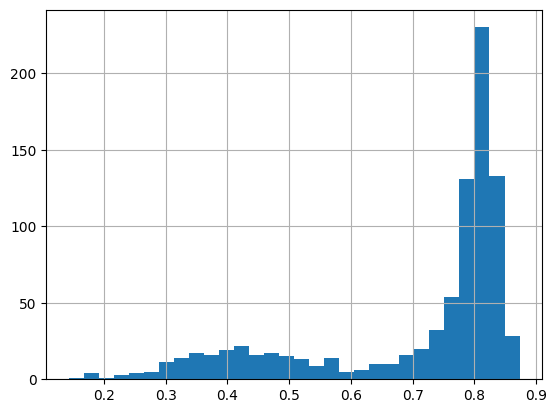

In [ ]:
df.metric_value.hist(bins=30)

<AxesSubplot:>

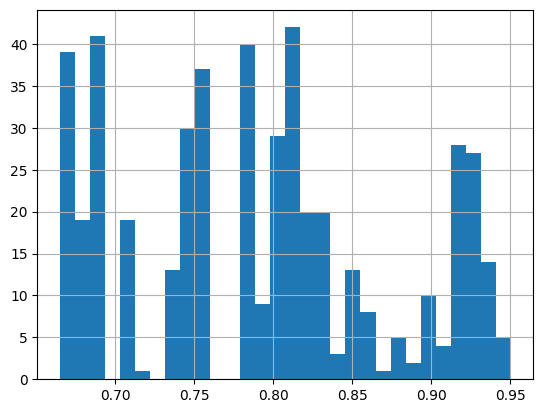

In [ ]:
df.metric_value.hist(bins=30) # qgan 

# plot at training convergence across parameter setting see if it needs retraining.. 
# at a function for metrics looking between catagorical and numeric to see the performacne (looks like it might be bad )